In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [21]:
df = pd.read_csv("Iris.csv") # make sure file is in same folder
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (150, 6)
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [23]:
X = df.iloc[:, :-1]   # all columns except last
y = df.iloc[:, -1]    # last column = label

In [25]:
X = X / 255.0

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 5)
Test shape: (30, 5)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(kernel='linear'),   # faster than default
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)}


In [31]:
results = {}

for name, model in models.items():
    print("\n==============================")
    print(f"Model: {name}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


Model: Logistic Regression
Accuracy: 0.9333333333333333
Confusion Matrix:
 [[10  0  0]
 [ 2  7  0]
 [ 0  0 11]]
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       0.83      1.00      0.91        10
Iris-versicolor       1.00      0.78      0.88         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30


Model: KNN
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted

In [33]:
print("\n====== Model Comparison ======")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")


====== Model Comparison ======
Logistic Regression: 0.9333
KNN: 1.0000
SVM: 1.0000
Decision Tree: 1.0000
Random Forest: 1.0000


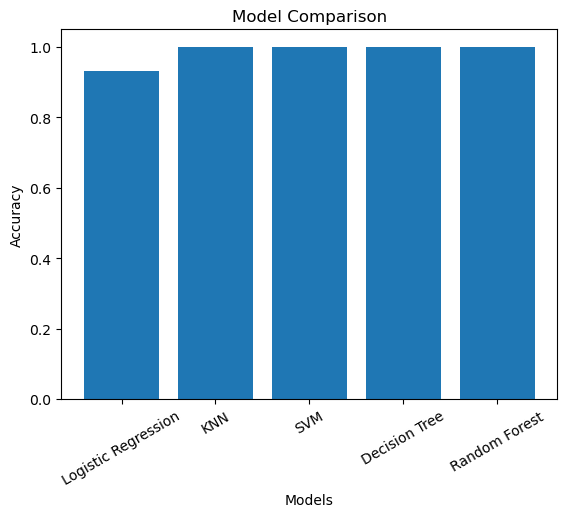

In [35]:
import matplotlib.pyplot as plt

names = list(results.keys())
values = list(results.values())

plt.figure()
plt.bar(names, values)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=30)
plt.show()